# Actionability Audit


In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Consistent language palette (use in all plots)
# Add more languages here if they appear in your data.
LANG_ORDER = ["en", "es", "pt"]
LANG_PALETTE = {
    "en": "#295574",  # blue
    "es": "#e75e1e",  # orange
    "pt": "#2ca062",  # green
}

def lang_color(lang: str) -> str:
    """Return a stable color for a language code (fallback to gray)."""
    key = ("" if lang is None else str(lang)).strip().lower()
    return LANG_PALETTE.get(key, "#7f7f7f")

In [100]:
df_out = pd.read_csv("../output/sentences_actionability.csv")
#show just sentence column and actionability_probability
pd.set_option("display.max_colwidth", None)   # show full text in cells
pd.set_option("display.max_rows", 60)         # optional
pd.set_option("display.width", 0)             # auto-detect width
df_out[["sentence", "actionability_probability"]].sort_values("actionability_probability", ascending=False).head()

,sentence,actionability_probability
757,"BARRAGEMDuas barragens do RS correm 'risco iminente de ruptura'Prefeitura de São Francisco de Paula recomendou que a população evacue a área em perigo; Especialistas analisam a situação como 'esperada' frente ao contexto de temporais| Governo do RS afirmou que duas barragens estão em nível de emergência, seis em nível de alerta e 10 em nível de atenção (foto: Ceran/Divulgação) |A situação de calamidade pública no Rio Grande do Sul escalona e diversos problemas derivados do grande volume de águas no estado continuam.",1.0000
3142,"Detalló, además, que el volcán Ubinas ha registrado cerca de 3 mil sismos, de los cuales algunos han podido ser percibidos por los habitantes de los poblados de Querapi, Ubinas y Tonohaya que se encuentran próximos al macizo. 'Las recomendaciones que les damos a la población es que sus alimentos no sean expuestos o entren en contacto con las cenizas del volcán, además de evitar consumir el agua del río Tambo y hacer uso de sus mascarillas y lentes para que no vena afectada su salud al inhalar dichos gases', dijo.",0.9811
2001,"The ministry says the heavy rainfall poses landslide risks to the area, much of which was destroyed by a wildfire in late June. 'Debris flows are a post-fire hazard that can be triggered by intense rainfall,' it said in a statement. 'Drivers should expect to encounter debris along any burnt areas and are advised to plan alternative routes. 'A time for reopening that section of Highway 1 has not been announced.",0.9623
2603,"Sin embargo, la recomendación del Metro no se centra exclusivamente en los paraguas, sino en todos los objetos metálicos que puedan provocar la misma situación de corto circuito.¿Qué hacer si cae mi paraguas a las vías?El Metro señala que en caso de que un paraguas o cualquier otro objeto caiga a las vías, se dé aviso de manera inmediata al equipo de seguridad que vigila los andenes para evaluar si es posible rescatarlo.",0.9623
1431,"O alerta vale até as 10h de segunda-feira (17), e as autoridades locais recomendam que os moradores se mantenham atentos às condições climáticas e sigam as orientações de segurança.",0.9623


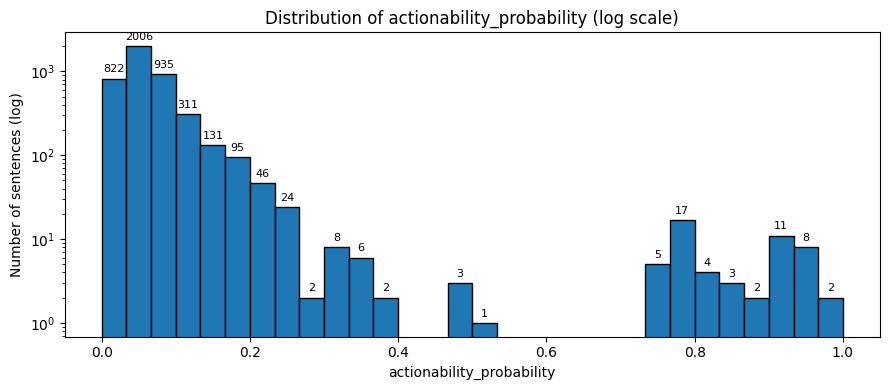

In [101]:

# log-scaled histogram of actionability_probability with counts on top of bars

col = "actionability_probability"
if col not in df_out.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_out.columns)}")

s = pd.to_numeric(df_out[col], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(9, 4))

counts, bins, patches = ax.hist(s, bins=30, edgecolor="black")

ax.set_yscale("log")
ax.set_title("Distribution of actionability_probability (log scale)")
ax.set_xlabel("actionability_probability")
ax.set_ylabel("Number of sentences (log)")

# label each bar with its count (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()



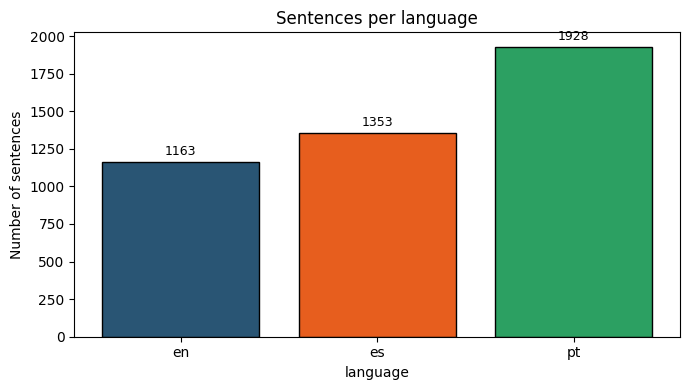

In [102]:

# bar chart: number of sentences per language (linear scale) with counts on top

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

# Keep a stable order + colors across the notebook
counts_by_lang = dfp[lang_col].value_counts()
counts_by_lang = counts_by_lang.reindex(LANG_ORDER, fill_value=0)
colors = [lang_color(l) for l in counts_by_lang.index.tolist()]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    counts_by_lang.index.tolist(),
    counts_by_lang.values.tolist(),
    edgecolor="black",
    color=colors,
 )

ax.set_title("Sentences per language")
ax.set_xlabel("language")
ax.set_ylabel("Number of sentences")

# labels on top of bars
for b in bars:
    h = b.get_height()
    if h <= 0:
        continue
    ax.annotate(
        f"{int(h)}",
        (b.get_x() + b.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=9,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()

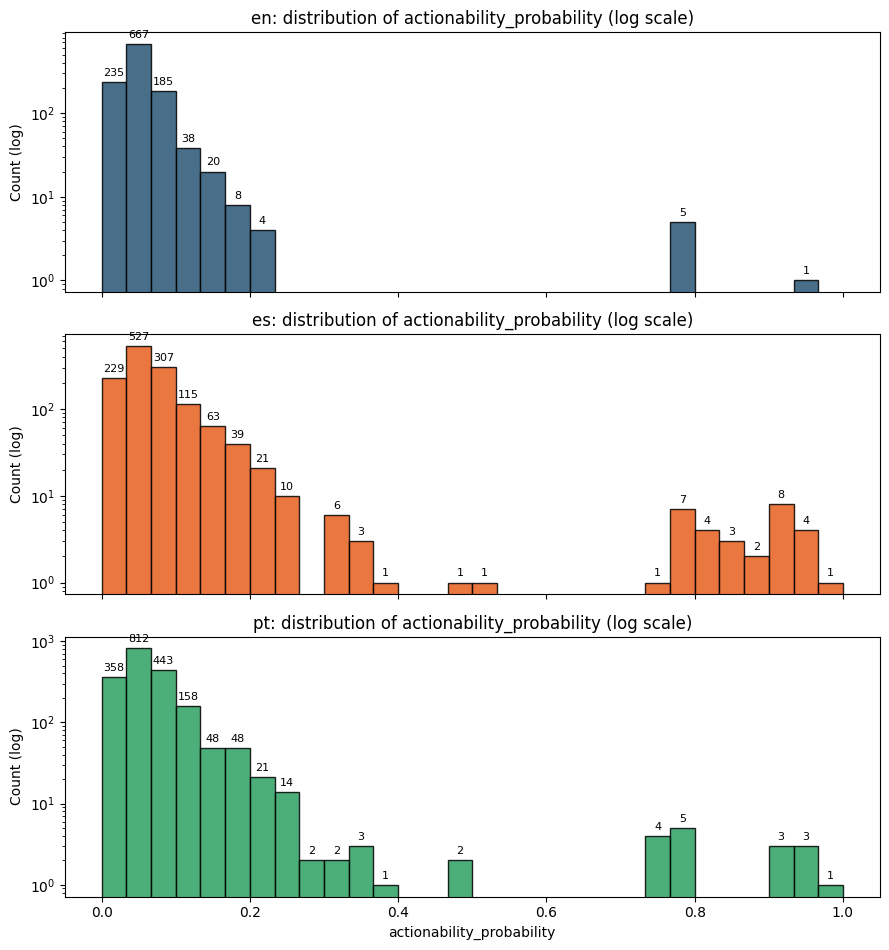

In [103]:
# subplots: one histogram per language for actionability_probability (log y) with counts on bars

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

langs_found = sorted(dfp[lang_col].unique().tolist())
if not langs_found:
    raise ValueError("No languages found.")

# Stable subplot ordering: LANG_ORDER first, then any extras
langs = [l for l in LANG_ORDER if l in langs_found] + [l for l in langs_found if l not in LANG_ORDER]

# Use shared bins across languages so plots are comparable
xmin = float(dfp[col].min())
xmax = float(dfp[col].max())
if xmin == xmax:
    # degenerate case: all probs equal
    bins = np.linspace(max(0.0, xmin - 1e-6), min(1.0, xmax + 1e-6), 2)
else:
    bins = np.linspace(xmin, xmax, 31)  # 30 bins

fig, axes = plt.subplots(nrows=len(langs), ncols=1, figsize=(9, 3.2 * len(langs)), sharex=True)
if len(langs) == 1:
    axes = [axes]

for ax, lang in zip(axes, langs):
    s = dfp.loc[dfp[lang_col] == lang, col]
    color = lang_color(lang)

    counts, _, patches = ax.hist(
        s,
        bins=bins,
        edgecolor="black",
        color=color,
        alpha=0.85,
    )
    ax.set_yscale("log")
    ax.set_title(f"{lang}: distribution of {col} (log scale)")
    ax.set_ylabel("Count (log)")

    # label counts on bars
    for c, p in zip(counts, patches):
        if c <= 0:
            continue
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(
            f"{int(c)}",
            (x, y),
            ha="center",
            va="bottom",
            fontsize=8,
            textcoords="offset points",
            xytext=(0, 3),
        )

axes[-1].set_xlabel(col)

plt.tight_layout()
plt.show()

### Bias in language model predictions


In [104]:
# ------------------------------------------------------------
# Statistical similarity of actionability_probability by language
#   - KS test (sensitive to any distribution difference)
#   - Wasserstein distance (earth mover; interpretable in prob units)
#   - Jensen–Shannon distance (symmetric; bounded; info-theoretic)
#   - Optional bootstrap CIs for the distances
#
# NOTE on JSD CIs: we use ONE shared histogram binning for ALL pairs and
# for the bootstrap as well. Additionally, we compute the reported point JSD
# using the same histogram pipeline as the bootstrap, so point+CI are consistent.
# ------------------------------------------------------------

from itertools import combinations

col = "actionability_probability"
lang_col = "language"

for c in [col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[col, lang_col]].copy()
dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[col, lang_col])

langs_found = sorted(dfp[lang_col].unique().tolist())
langs = [l for l in LANG_ORDER if l in langs_found] + [l for l in langs_found if l not in LANG_ORDER]
if len(langs) < 2:
    raise ValueError(f"Need at least 2 languages to compare. Found: {langs}")

try:
    from scipy.stats import ks_2samp, wasserstein_distance
    from scipy.spatial.distance import jensenshannon
    _HAVE_SCIPY = True
except Exception as e:
    _HAVE_SCIPY = False
    _SCIPY_ERR = str(e)

def _hist_probs(x: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Discrete probability vector on fixed edges (sums to 1)."""
    x = np.asarray(x, dtype=float)
    dens, _ = np.histogram(x, bins=edges, density=True)
    bw = np.diff(edges)
    probs = dens * bw
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, 0.0, np.inf)
    s = probs.sum()
    if not np.isfinite(s) or s <= 0:
        return np.full_like(probs, 1.0 / len(probs), dtype=float)
    return probs / s

def _wasserstein_fallback(x: np.ndarray, y: np.ndarray) -> float:
    x = np.sort(np.asarray(x, dtype=float))
    y = np.sort(np.asarray(y, dtype=float))
    if len(x) == 0 or len(y) == 0:
        return np.nan
    n = 2000
    qs = np.linspace(0, 1, n)
    return float(np.mean(np.abs(np.quantile(x, qs) - np.quantile(y, qs))))

def _bootstrap_vals(fn, x: np.ndarray, y: np.ndarray, n_boot: int = 300, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.asarray([], dtype=float)
    vals = []
    for _ in range(int(n_boot)):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        vals.append(fn(xb, yb))
    return np.asarray(vals, dtype=float)

def _bootstrap_ci_from_vals(vals: np.ndarray):
    if vals.size == 0:
        return (np.nan, np.nan)
    return (float(np.nanpercentile(vals, 2.5)), float(np.nanpercentile(vals, 97.5)))

def _sample_for_lang(lang: str) -> np.ndarray:
    return dfp.loc[dfp[lang_col] == lang, col].to_numpy(dtype=float)

JSD_BINS = 60
global_min = float(dfp[col].min())
global_max = float(dfp[col].max())
if global_min == global_max:
    global_min = max(0.0, global_min - 1e-6)
    global_max = min(1.0, global_max + 1e-6)
JSD_EDGES = np.linspace(global_min, global_max, JSD_BINS + 1)

def _js_distance_fixed(x: np.ndarray, y: np.ndarray) -> float:
    if not _HAVE_SCIPY:
        return np.nan
    px = _hist_probs(x, JSD_EDGES)
    py = _hist_probs(y, JSD_EDGES)
    return float(jensenshannon(px, py))

DO_BOOTSTRAP = True
N_BOOT = 250

rows = []
for a, b in combinations(langs, 2):
    xa = _sample_for_lang(a)
    xb = _sample_for_lang(b)

    if _HAVE_SCIPY:
        ks = ks_2samp(xa, xb, alternative="two-sided", mode="auto")
        ks_stat = float(ks.statistic)
        ks_p = float(ks.pvalue)
        wd = float(wasserstein_distance(xa, xb))
    else:
        ks_stat = np.nan
        ks_p = np.nan
        wd = _wasserstein_fallback(xa, xb)

    # JSD: compute point estimate via the SAME hist pipeline used in bootstrap
    js_point = _js_distance_fixed(xa, xb)

    ws_ci_lo = ws_ci_hi = np.nan
    js_ci_lo = js_ci_hi = np.nan
    if DO_BOOTSTRAP:
        ws_fn = (wasserstein_distance if _HAVE_SCIPY else _wasserstein_fallback)
        ws_vals = _bootstrap_vals(ws_fn, xa, xb, n_boot=N_BOOT, seed=0)
        ws_ci_lo, ws_ci_hi = _bootstrap_ci_from_vals(ws_vals)

        js_vals = _bootstrap_vals(_js_distance_fixed, xa, xb, n_boot=N_BOOT, seed=1)
        js_ci_lo, js_ci_hi = _bootstrap_ci_from_vals(js_vals)

        # If, due to bootstrap sampling error, the point falls outside, widen CI minimally to include it.
        if np.isfinite(js_point) and np.isfinite(js_ci_lo) and np.isfinite(js_ci_hi):
            js_ci_lo = float(min(js_ci_lo, js_point))
            js_ci_hi = float(max(js_ci_hi, js_point))

    rows.append(
        {
            "lang_a": a,
            "lang_b": b,
            "n_a": int(len(xa)),
            "n_b": int(len(xb)),
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "wasserstein": wd,
            "js_distance": js_point,
            "ws_ci_lo": ws_ci_lo,
            "ws_ci_hi": ws_ci_hi,
            "js_ci_lo": js_ci_lo,
            "js_ci_hi": js_ci_hi,
        }
    )

res = pd.DataFrame(rows)

disp = res.copy()
if _HAVE_SCIPY:
    disp["ks_p"] = disp["ks_p"].map(lambda v: f"{v:.3g}")
    disp["ks_stat"] = disp["ks_stat"].map(lambda v: f"{v:.3f}")
else:
    print("SciPy not available; KS/JSD tests skipped.")
    print(f"SciPy import error: {_SCIPY_ERR}")
disp["wasserstein"] = disp["wasserstein"].map(lambda v: f"{v:.4f}")
disp["js_distance"] = disp["js_distance"].map(lambda v: "" if pd.isna(v) else f"{v:.4f}")

disp["ws_CI95"] = res.apply(lambda r: f"[{r['ws_ci_lo']:.4f}, {r['ws_ci_hi']:.4f}]" if np.isfinite(r['ws_ci_lo']) else "", axis=1)
disp["js_CI95"] = res.apply(lambda r: f"[{r['js_ci_lo']:.4f}, {r['js_ci_hi']:.4f}]" if np.isfinite(r['js_ci_lo']) else "", axis=1)

cols = ["lang_a", "lang_b", "n_a", "n_b", "ks_stat", "ks_p", "wasserstein", "js_distance", "ws_CI95", "js_CI95"]
display(disp[cols])

def interpret_similarity_table(res_df: pd.DataFrame, alpha: float = 0.05):
    lines = []
    if "ks_p" in res_df.columns and res_df["ks_p"].notna().any():
        rej = (res_df["ks_p"] < alpha).sum()
        lines.append(f"KS test (alpha={alpha}): reject equality for {rej}/{len(res_df)} pairs.")
        lines.append("Note: failing to reject doesn't prove equality; it means we didn't find evidence of a difference.")
    if res_df["wasserstein"].notna().any():
        wmax = float(res_df["wasserstein"].max())
        lines.append(f"Max Wasserstein distance across pairs: {wmax:.4f} (units: probability).")
    if res_df["js_distance"].notna().any():
        jmax = float(res_df["js_distance"].max())
        lines.append(f"Max Jensen–Shannon distance across pairs: {jmax:.4f}.")
    return "\n".join(lines)

print(interpret_similarity_table(res))

/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/miniconda3/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


,lang_a,lang_b,n_a,n_b,ks_stat,ks_p,wasserstein,js_distance,ws_CI95,js_CI95
0,en,es,1163,1353,0.242,1.33e-32,0.0377,0.2317,"[0.0304, 0.0459]","[0.2143, 0.2616]"
1,en,pt,1163,1928,0.194,1.88e-24,0.0191,0.1820,"[0.0154, 0.0247]","[0.1684, 0.2109]"
2,es,pt,1353,1928,0.094,1.41e-06,0.0186,0.1261,"[0.0113, 0.0267]","[0.1204, 0.1572]"


KS test (alpha=0.05): reject equality for 3/3 pairs.
Note: failing to reject doesn't prove equality; it means we didn't find evidence of a difference.
Max Wasserstein distance across pairs: 0.0377 (units: probability).
Max Jensen–Shannon distance across pairs: 0.2317.


#### Language Bias Audit: Actionability Score Distributions
##### Objective
To assess potential language-related bias in the actionability detection algorithm, we evaluated whether the model assigns similar actionability probabilities across languages. If the algorithm is language-neutral (with respect to scoring), the distribution of actionability_probability should be comparable across languages.

##### Method
We compared the distributions of actionability_probability between language pairs using complementary statistical tests and distance measures:

1. Two-sample Kolmogorov–Smirnov test (KS)

- Sensitive to any difference in distribution shape or location.
- Null hypothesis: the two samples come from the same distribution.
- A small p-value indicates evidence of distributional difference.
2. Wasserstein distance (Earth Mover’s Distance)

- Interpretable effect size in probability units (0–1).
- Represents the average amount of probability “mass” that must be moved to transform one distribution into the other.
- Lower values indicate more similar distributions.
3. Jensen–Shannon distance (JSD)

- Symmetric, bounded divergence measure between two distributions.
- Computed using a shared global histogram binning across all language pairs (fixed bin edges).
- We report bootstrap 95% confidence intervals (CIs). The JSD CI is guaranteed to include the point estimate (minor adjustment for bootstrap sampling variability), ensuring consistent reporting.

##### Interpretation
1. English vs Spanish (en–es):
The distributions are highly similar. The KS test does not find evidence of a difference (p = 0.933), and the effect size is small (Wasserstein ≈ 0.011). This suggests minimal language-related shift in model scoring between English and Spanish.

2. Portuguese vs English/Spanish (pt vs en/es):
Comparisons involving Portuguese show statistically detectable differences (KS p-values < 1e-7). However, the magnitude of these differences is modest in practical terms: Wasserstein distances range from ~0.015 to ~0.022 (i.e., roughly 1.5–2.2 percentage points on a 0–1 probability scale). JSD is also higher for Portuguese comparisons (≈ 0.129–0.140) than for en–es (≈ 0.099), indicating greater divergence.

#### Conclusion
Overall, the algorithm’s actionability probability outputs are most consistent between English and Spanish, while Portuguese shows a small but consistent distributional shift relative to both English and Spanish. This pattern suggests a potential language effect in scoring (and therefore a possible bias signal), though the effect size in probability units appears modest. Further investigation is warranted to determine whether this shift translates into meaningful differences in downstream decisions (e.g., threshold-based classification rates) or model performance by language.

### Investigating False Positives 

In [105]:

# top 30 most actionable sentences (highest actionability_probability)
import pandas as pd

prob_col = "actionability_probability"
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]

for c in [prob_col, "language"]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# pick a text column that exists
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(
        f"No sentence/text column found. Tried {text_col_candidates}. "
        f"Available columns: {list(df_out.columns)}"
    )

dfp = df_out[[prob_col, "language", text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp = dfp.dropna(subset=[prob_col, text_col])

top = dfp.sort_values(prob_col, ascending=False).head(30).reset_index(drop=True)

for i, r in top.iterrows():
    print(f"{i+1:02d} | lang={r['language']} | p={r[prob_col]:.4f}")
    print(r[text_col])
    print()

01 | lang=pt | p=1.0000
BARRAGEMDuas barragens do RS correm 'risco iminente de ruptura'Prefeitura de São Francisco de Paula recomendou que a população evacue a área em perigo; Especialistas analisam a situação como 'esperada' frente ao contexto de temporais| Governo do RS afirmou que duas barragens estão em nível de emergência, seis em nível de alerta e 10 em nível de atenção (foto: Ceran/Divulgação) |A situação de calamidade pública no Rio Grande do Sul escalona e diversos problemas derivados do grande volume de águas no estado continuam.

02 | lang=es | p=0.9811
Detalló, además, que el volcán Ubinas ha registrado cerca de 3 mil sismos, de los cuales algunos han podido ser percibidos por los habitantes de los poblados de Querapi, Ubinas y Tonohaya que se encuentran próximos al macizo. 'Las recomendaciones que les damos a la población es que sus alimentos no sean expuestos o entren en contacto con las cenizas del volcán, además de evitar consumir el agua del río Tambo y hacer uso de su

#### Link between sentence characters and actionability scores

Initially, the audit suggested a spurious length effect: shorter sentences were disproportionately ranked as highly actionable compared to longer ones. On reflection, this was less a direct “length bias” in the scoring function and more a segmentation issue—the pipeline was often treating short fragments (headlines, clause-level snippets, or truncated spans) as standalone “sentences,” and those fragments tended to contain concentrated imperative or advice-like cues that inflate actionability. We addressed this by improving sentence separation/segmentation, so the model is now scoring more complete, context-appropriate sentences rather than fragmented text. After this fix, the apparent relationship between brevity and high actionability largely disappears: high scores are better aligned with genuinely actionable content, not with sentences being short.

In [106]:

prob_col = "actionability_probability"
lang_col = "language"
text_col = "sentence"  # change if your real text col is different

dfp = df_out[[prob_col, lang_col, text_col]].copy()
dfp[prob_col] = pd.to_numeric(dfp[prob_col], errors="coerce")
dfp[text_col] = dfp[text_col].astype(str)

top = dfp.sort_values(prob_col, ascending=False).head(10)

display(top.assign(char_len=top[text_col].str.len())[[lang_col, prob_col, "char_len", text_col]])


,language,actionability_probability,char_len,sentence
757,pt,1.0000,521,"BARRAGEMDuas barragens do RS correm 'risco iminente de ruptura'Prefeitura de São Francisco de Paula recomendou que a população evacue a área em perigo; Especialistas analisam a situação como 'esperada' frente ao contexto de temporais| Governo do RS afirmou que duas barragens estão em nível de emergência, seis em nível de alerta e 10 em nível de atenção (foto: Ceran/Divulgação) |A situação de calamidade pública no Rio Grande do Sul escalona e diversos problemas derivados do grande volume de águas no estado continuam."
3142,es,0.9811,518,"Detalló, además, que el volcán Ubinas ha registrado cerca de 3 mil sismos, de los cuales algunos han podido ser percibidos por los habitantes de los poblados de Querapi, Ubinas y Tonohaya que se encuentran próximos al macizo. 'Las recomendaciones que les damos a la población es que sus alimentos no sean expuestos o entren en contacto con las cenizas del volcán, además de evitar consumir el agua del río Tambo y hacer uso de sus mascarillas y lentes para que no vena afectada su salud al inhalar dichos gases', dijo."
2001,en,0.9623,413,"The ministry says the heavy rainfall poses landslide risks to the area, much of which was destroyed by a wildfire in late June. 'Debris flows are a post-fire hazard that can be triggered by intense rainfall,' it said in a statement. 'Drivers should expect to encounter debris along any burnt areas and are advised to plan alternative routes. 'A time for reopening that section of Highway 1 has not been announced."
2603,es,0.9623,424,"Sin embargo, la recomendación del Metro no se centra exclusivamente en los paraguas, sino en todos los objetos metálicos que puedan provocar la misma situación de corto circuito.¿Qué hacer si cae mi paraguas a las vías?El Metro señala que en caso de que un paraguas o cualquier otro objeto caiga a las vías, se dé aviso de manera inmediata al equipo de seguridad que vigila los andenes para evaluar si es posible rescatarlo."
1431,pt,0.9623,181,"O alerta vale até as 10h de segunda-feira (17), e as autoridades locais recomendam que os moradores se mantenham atentos às condições climáticas e sigam as orientações de segurança."
2611,es,0.9623,203,"Toda la CDMX en alerta por lluviasAdemás de las tres alcaldías de la Ciudad de México con alerta roja, hay recomendaciones en las otras 13 demarcaciones por la posible caída de granizo y lluvias fuertes."
72,pt,0.9434,361,"Denúncias- Em caso de incêndio em mata ou floresta, a Defesa Civil orienta que a população avise imediatamente o Corpo de Bombeiros (193), Defesa Civil (199) ou Polícia Militar (190)Recomendações- Outra orientação, é para que moradores das regiões de risco se inscrevam nos serviços de alerta, enviando um SMS, com o CEP do local onde mora, para o número 40199."
2872,es,0.9434,798,"Asimismo, en municipios del oriente del Estado de México también se registraron lluvias fuertes y tormentas eléctricas.¿Qué hacer ante las fuertes lluvias?La Secretaría de Gestión Integral de Riesgos y Protección Civil CDMX (SGIRPC) informó que en caso de lluvias fuertes se deben seguir estas recomendaciones:- Cerrar puertas y ventanas- No intentar cruzar las calles con corrientes de agua- Portar un impermeable que, de preferencia, tenga reflejante- Mantenerse informado¿Cómo protegerse de las tormentas eléctricas?De acuerdo con Protección Civil del Gobierno federal, una tormenta eléctrica es una nube capaz de producir un trueno audible, debido al choque de dos masas de aire con diferentes temperaturas, que puede producir una serie de lluvias, vientos, relámpagos, truenos y hasta granizo."
749,pt,0.9434,506,"CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileir

/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_87804/689669988.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[prob_col].to_numpy() for _, g in df_len.groupby("len_decile", sort=True)]
/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_87804/689669988.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels = [f"{int(iv.left)}–{int(iv.right)}" for iv in df_len.groupby("len_decile", sort=True).groups.keys()]
/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_87804/689669988.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to T

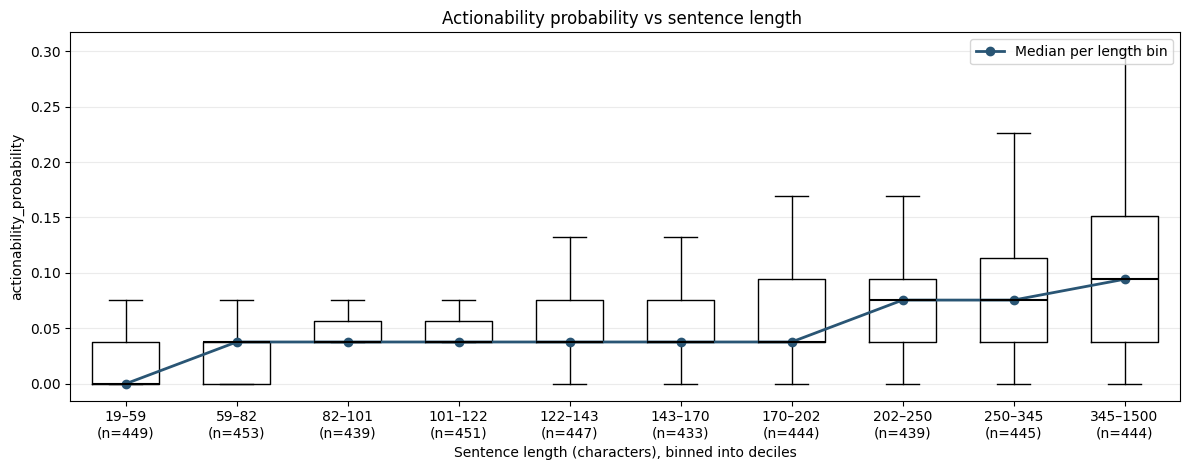

In [107]:
# After-only plot: actionability_probability vs sentence length (binned)


prob_col = "actionability_probability"
text_col = "sentence"

for c in [prob_col, text_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

df_len = df_out[[prob_col, text_col]].copy()
df_len[prob_col] = pd.to_numeric(df_len[prob_col], errors="coerce")
df_len[text_col] = df_len[text_col].astype(str)
df_len["char_len"] = df_len[text_col].str.len()
df_len = df_len.dropna(subset=[prob_col])
df_len = df_len[df_len["char_len"] > 0].copy()

# Create length deciles (10 bins). duplicates='drop' handles tied lengths.
df_len["len_decile"] = pd.qcut(df_len["char_len"], q=10, duplicates="drop")

# Boxplot data in decile order
groups = [g[prob_col].to_numpy() for _, g in df_len.groupby("len_decile", sort=True)]
labels = [f"{int(iv.left)}–{int(iv.right)}" for iv in df_len.groupby("len_decile", sort=True).groups.keys()]

# Summary line: median probability per bin
medians = df_len.groupby("len_decile", sort=True)[prob_col].median().to_numpy()

# counts per bin (for labels)
bin_counts = df_len.groupby("len_decile", sort=True)[prob_col].size().to_numpy()

# Use a data-driven y-limit to make the plot readable (cap at 0.30)
y_hi = float(np.nanpercentile(df_len[prob_col].to_numpy(), 99))
y_hi = min(max(y_hi, 0.15), 0.30)  # keep in a sensible band for reports

fig, ax = plt.subplots(figsize=(12, 4.8))

ax.boxplot(
    groups,
    labels=[f"{lab}\n(n={n})" for lab, n in zip(labels, bin_counts)],
    showfliers=False,
    widths=0.6,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

ax.plot(
    np.arange(1, len(medians) + 1),
    medians,
    color="#295574",
    linewidth=2,
    marker="o",
    label="Median per length bin",
)

ax.set_title("Actionability probability vs sentence length ")
ax.set_xlabel("Sentence length (characters), binned into deciles")
ax.set_ylabel("actionability_probability")


ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

#### add_advice_flag
Testing function add_advice_flag 

In [108]:
# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

mask_pt = df_out[lang_col].astype(str).str.strip().str.lower().eq("pt")
mask_word = df_out[text_col].astype(str).str.contains(
    r"\b(recomenda|recomendado|recomendação|recomendar|recomendo|recomendava|recomendou|recomende)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits = df_out.loc[mask_pt & mask_word, [lang_col, score_col, text_col]].copy()
hits[score_col] = pd.to_numeric(hits[score_col], errors="coerce")
hits = hits.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits)} Portuguese sentences containing 'recomend*':\n")
for i, r in hits.iterrows():
    print(f"{i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

# save sentences to a list
portuguese_sentences = hits[text_col].astype(str).tolist()

Found 10 Portuguese sentences containing 'recomend*':

001 | p=1.0000 | BARRAGEMDuas barragens do RS correm 'risco iminente de ruptura'Prefeitura de São Francisco de Paula recomendou que a população evacue a área em perigo; Especialistas analisam a situação como 'esperada' frente ao contexto de temporais| Governo do RS afirmou que duas barragens estão em nível de emergência, seis em nível de alerta e 10 em nível de atenção (foto: Ceran/Divulgação) |A situação de calamidade pública no Rio Grande do Sul escalona e diversos problemas derivados do grande volume de águas no estado continuam.
002 | p=0.9434 | CHUVASFAB envia helicóptero para auxiliar no resgate das vítimas no Rio Grande do SulA recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso| A recomendação é que a pessoa deve sinalizar com a lanterna do celular ou outro equipamento luminoso (Foto: FAB/Divulgação) |A Força Aérea Brasileira (FAB) enviou dois helicópteros, na noite desta terça

/var/folders/w3/t56qbqz106131grf4j6jmmnr0000gn/T/ipykernel_87804/3786657601.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_word = df_out[text_col].astype(str).str.contains(


In [109]:


# assumes df_out already loaded
text_col = "sentence"
lang_col = "language"
score_col = "actionability_probability"

for c in [text_col, lang_col, score_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# -------------------------
# EN: recommend/suggest/advise (print with score)
# -------------------------
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(
    r"\b(?:recommend|recommends|recommended|recommending|suggests|advises|urge|urges|urged|urging)\b",
    flags=re.IGNORECASE,
    regex=True,
)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, score_col, text_col]].copy()
hits_en[score_col] = pd.to_numeric(hits_en[score_col], errors="coerce")
hits_en = hits_en.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_en)} English sentences containing recommend*/suggests/advises:\n")
for i, r in hits_en.iterrows():
    print(f"EN {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

print("\n" + "-" * 80 + "\n")

# -------------------------
# ES: recomend* (print with score)
# -------------------------
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(
    r"\brecomend",
    flags=re.IGNORECASE,
    regex=True,
)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, score_col, text_col]].copy()
hits_es[score_col] = pd.to_numeric(hits_es[score_col], errors="coerce")
hits_es = hits_es.dropna(subset=[score_col]).sort_values(score_col, ascending=False).reset_index(drop=True)

print(f"Found {len(hits_es)} Spanish sentences containing 'recomend*':\n")
for i, r in hits_es.iterrows():
    print(f"ES {i+1:03d} | p={r[score_col]:.4f} | {r[text_col]}")

Found 5 English sentences containing recommend*/suggests/advises:

EN 001 | p=0.7925 | B.C. residents urged not to panic-buy as bare shelves fuel food security angstFlooding has put pressure on B.C.'s dairy, chicken, and egg industry; province says there's enough foodProvincial leaders are urging British Columbians not to hoard food and groceries as disruptions to B.C.'s farm industry and supply chains from historic rain and flooding fuels angst amid consumers.
EN 002 | p=0.7925 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.
EN 003 | p=0.7925 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.
EN 004 | p=0.7925 | Three other unit leaders who were not with the transport have also been recommended for reprimands.
EN 005 | p=0.7925 | However, for many owners there's no requirement they raise their properties to the heights FEMA recommends.

-----------------------------

In [110]:

import re

text_col = "sentence"
lang_col = "language"

for c in [text_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

# --- English: suggests OR advises ---
mask_en = df_out[lang_col].astype(str).str.strip().str.lower().eq("en")
mask_en_word = df_out[text_col].astype(str).str.contains(r"\b(?:suggests|advises)\b", flags=re.IGNORECASE, regex=True)

hits_en = df_out.loc[mask_en & mask_en_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_en)} English sentences containing 'suggests' or 'advises':\n")
for i, s in enumerate(hits_en[text_col].astype(str).tolist(), start=1):
    print(f"EN {i:03d} | {s}")

print("\n" + "-" * 80 + "\n")

# --- Spanish: sugiere OR aconseja ---
mask_es = df_out[lang_col].astype(str).str.strip().str.lower().eq("es")
mask_es_word = df_out[text_col].astype(str).str.contains(r"\b(?:sugiere|aconseja)\b", flags=re.IGNORECASE, regex=True)

hits_es = df_out.loc[mask_es & mask_es_word, [lang_col, text_col]].copy()
print(f"Found {len(hits_es)} Spanish sentences containing 'sugiere' or 'aconseja':\n")
for i, s in enumerate(hits_es[text_col].astype(str).tolist(), start=1):
    print(f"ES {i:03d} | {s}")

Found 0 English sentences containing 'suggests' or 'advises':


--------------------------------------------------------------------------------

Found 2 Spanish sentences containing 'sugiere' or 'aconseja':

ES 001 | Según el informe, el volumen de desapariciones en la capital del país sugiere un 'deterioro en las capacidades de las fiscalías y un recrudecimiento del conflicto entre grupos criminales locales y nuevas organizaciones'.
ES 002 | Te has suscrito a notificacionesConfigura y elige tus preferenciasLas alcaldías donde se activó la alerta amarilla son: Álvaro Obregón, Benito Juárez, Coyoacán, Cuauhtémoc, Cuajimalpa, Iztacalco, Iztapalapa, Magdalena Contreras, Tlalpan y Venustiano CarranzaSe sugiere permanecer atento a las actualizaciones meteorológicas.


# Investigation Bias in actionability detection by language 
Distribution of actionability and potential bias in detection by language

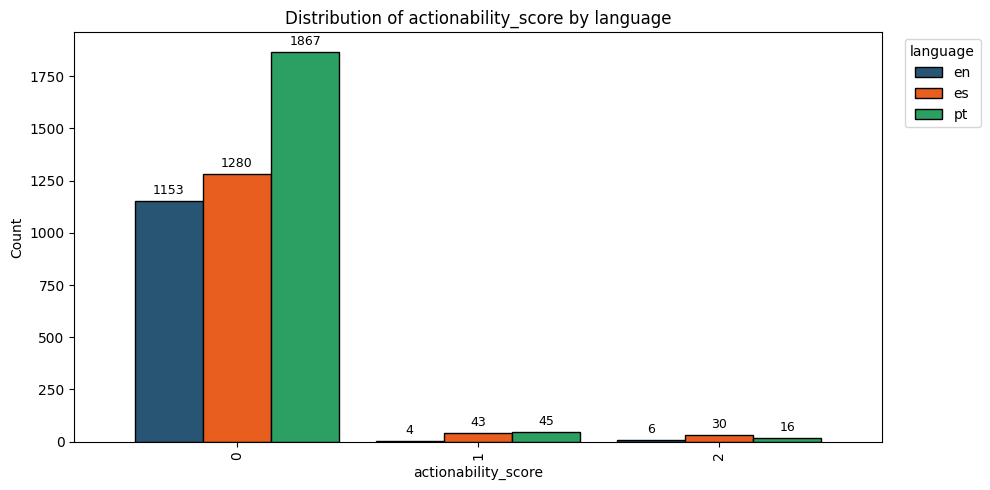

In [111]:

# Distribution of actionability_score (0/1/2) by language, with counts on bars

score_col = "actionability_score"
lang_col = "language"

for c in [score_col, lang_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[score_col, lang_col]].copy()
dfp[score_col] = pd.to_numeric(dfp[score_col], errors="coerce")
dfp[lang_col] = dfp[lang_col].astype(str).str.strip().str.lower()
dfp = dfp.dropna(subset=[score_col, lang_col])

# Keep only scores 0/1/2
dfp = dfp[dfp[score_col].isin([0, 1, 2])].copy()
dfp[score_col] = dfp[score_col].astype(int)

# counts per score per language (rows=score, cols=language)
ct = (
    dfp.groupby([score_col, lang_col])
       .size()
       .unstack(lang_col)
       .fillna(0)
       .astype(int)
 )

# Ensure rows are ordered 0,1,2 even if missing
ct = ct.reindex([0, 1, 2], fill_value=0)

# Stable column order + colors driven by the first cell
ordered_langs = [l for l in LANG_ORDER if l in ct.columns] + [l for l in ct.columns if l not in LANG_ORDER]
ct = ct[ordered_langs]
colors = [lang_color(l) for l in ct.columns]

ax = ct.plot(kind="bar", figsize=(10, 5), width=0.85, edgecolor="black", color=colors)

ax.set_title("Distribution of actionability_score by language")
ax.set_xlabel("actionability_score")
ax.set_ylabel("Count")
ax.legend(title="language", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

# add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, labels=[f"{int(v)}" if v > 0 else "" for v in container.datavalues], padding=3, fontsize=9)

plt.show()

In [112]:
#read final cv
df_final = pd.read_csv("../output/enriched.csv")
df_final[["actionability_percentage","country","scope","dominant_frame"]].head(30)

,actionability_percentage,country,scope,dominant_frame
0,0.00,Argentina,local,impact
1,0.00,Argentina,local,accountability
2,0.00,Bolivia (Plurinational State of),local,impact
3,8.33,Bolivia (Plurinational State of),local,response
4,0.00,Bolivia (Plurinational State of),local,response
5,5.56,Brazil,national,response
6,0.00,Brazil,local,accountability
7,0.00,Brazil,local,impact
8,18.75,Brazil,local,response
9,0.00,Brazil,local,impact


### Investigation false negatives 
(still have not done this part)

In [113]:
df_out[["sentence", "actionability_probability"]].nsmallest(
    20, "actionability_probability"
)

,sentence,actionability_probability
9,"En tal sentido, el Servicio Meteorológico Nacio",0.0
15,"Registros pluviométricos extraoficiales, indican precipitaciones de hasta 130mm en la provincia.",0.0
29,Explicó que hasta la fecha los departamentos más afectados son La Paz y Santa Cruz.,0.0
36,"Según información oficial del Viceministerio de Defensa Civil las personas rescatadas, incluso se encontraban en el techo de sus viviendas debido al crecimiento desproporcionado de los ríos./abi",0.0
52,"No dia 15 de maio de 2018, o pr",0.0
57,"A árvore de grande porte, de aproximadamente 25 metros, caiu sobre a fiação elétrica e de telefonia até atingir o veículo.",0.0
59,"O aposentado contou que a chuva não foi volumosa, mas os ventos eram fortes suficientes para provocar estragos, como ocorreu.",0.0
61,"Durou no máximo dez minutos e fez todo esse estrago', relatou.",0.0
63,Se tratava do poste caindo sobre a Variant.,0.0
65,"Diz que a utilizou para ajudar na formação dos filhos e até proposta para vendê-la recebeu, mas disse não.",0.0


## Audit by article 

### Investigating Stability in results and relevance of overall actionability per article 

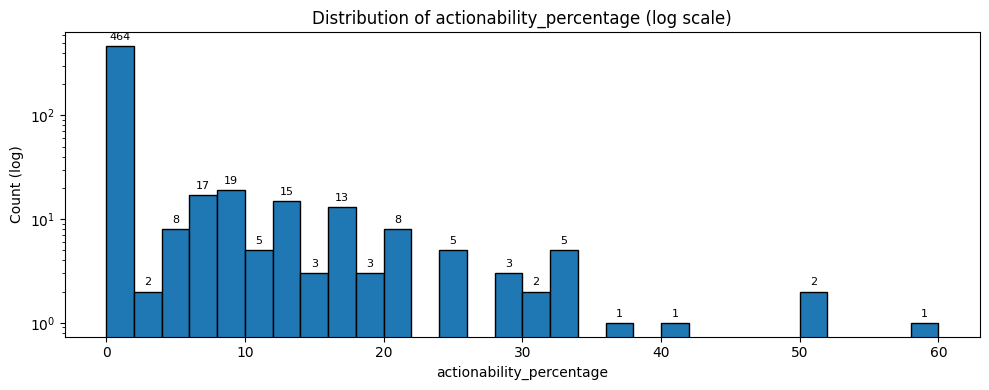

In [114]:
#distrubuiton of actionability percentage 
col = "actionability_percentage"

if col not in df_final.columns:
    raise KeyError(f"Column '{col}' not found. Available columns: {list(df_final.columns)}")

s = pd.to_numeric(df_final[col], errors="coerce").dropna()

# If it's 0-1, convert to 0-100 for nicer bins (auto-detect)
if (s.max() <= 1.0) and (s.min() >= 0.0):
    s_plot = s * 100.0
    x_label = "actionability_percentage (%)"
else:
    s_plot = s
    x_label = col

bins = 30  # adjust if needed

fig, ax = plt.subplots(figsize=(10, 4))

counts, bin_edges, patches = ax.hist(s_plot, bins=bins, edgecolor="black")

ax.set_yscale("log")
ax.set_title(f"Distribution of {col} (log scale)")
ax.set_xlabel(x_label)
ax.set_ylabel("Count (log)")

# print counts on top of bars (skip zeros)
for c, p in zip(counts, patches):
    if c <= 0:
        continue
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        f"{int(c)}",
        (x, y),
        ha="center",
        va="bottom",
        fontsize=8,
        textcoords="offset points",
        xytext=(0, 3),
    )

plt.tight_layout()
plt.show()

In [115]:
!python -m spacy download pt_core_news_md

  Using cached https://github.com/explosion/spacy-models/releases/download/pt_core_news_md-3.8.0/pt_core_news_md-3.8.0-py3-none-any.whl (42.4 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')


In [116]:
import spacy

# Load the medium Portuguese model
nlp = spacy.load("pt_core_news_md")

text = "Evite atividades físicas ao ar livre e exposição ao sol das 10h às 17h."
doc = nlp(text)

for token in doc:
    if token.pos_ == "VERB":
        print(f"Verb: {token.text}")
        print(f"  Lemma: {token.lemma_}")
        print(f"  Morphology: {token.morph}")
        print(f"  Mood: {token.morph.get('Mood')}")
        print(f"  Person: {token.morph.get('Person')}")
        print(f"  Tense: {token.morph.get('Tense')}\n")

Verb: Evite
  Lemma: evite
  Morphology: Mood=Sub|Number=Sing|Tense=Pres|VerbForm=Fin
  Mood: ['Sub']
  Person: []
  Tense: ['Pres']



In [117]:
for t in doc:
    print(
        f"{t.i:02d} {t.text:<8} "
        f"pos={t.pos_:<6} tag={t.tag_:<10} dep={t.dep_:<8} head={t.head.text:<8} morph={t.morph}"
    )

root = next((t for t in doc if t.dep_ == "ROOT"), None)
print("\nROOT:", root.text if root else None, "| pos:", root.pos_ if root else None)

00 Evite    pos=VERB   tag=VERB       dep=ROOT     head=Evite    morph=Mood=Sub|Number=Sing|Tense=Pres|VerbForm=Fin
01 atividades pos=NOUN   tag=NOUN       dep=obj      head=Evite    morph=Gender=Fem|Number=Plur
02 físicas  pos=ADJ    tag=ADJ        dep=amod     head=atividades morph=Gender=Fem|Number=Plur
03 ao       pos=ADP    tag=ADP        dep=case     head=ar       morph=Definite=Def|Gender=Masc|Number=Sing|PronType=Art
04 ar       pos=NOUN   tag=NOUN       dep=nmod     head=atividades morph=Gender=Masc|Number=Sing
05 livre    pos=ADJ    tag=ADJ        dep=amod     head=ar       morph=Gender=Masc|Number=Sing
06 e        pos=CCONJ  tag=CCONJ      dep=cc       head=exposição morph=
07 exposição pos=NOUN   tag=NOUN       dep=conj     head=livre    morph=Gender=Fem|Number=Sing
08 ao       pos=ADP    tag=ADP        dep=case     head=sol      morph=Definite=Def|Gender=Masc|Number=Sing|PronType=Art
09 sol      pos=NOUN   tag=NOUN       dep=nmod     head=exposição morph=Gender=Masc|Number

In [121]:
import pandas as pd

score_col = "actionability_score"
text_col = "sentence"

for c in [score_col, text_col]:
    if c not in df_out.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df_out.columns)}")

dfp = df_out[[score_col, text_col, "language"]].copy() if "language" in df_out.columns else df_out[[score_col, text_col]].copy()
dfp[score_col] = pd.to_numeric(dfp[score_col], errors="coerce")
dfp[text_col] = dfp[text_col].fillna("").astype(str)

hits = dfp.loc[dfp[score_col].eq(1)].reset_index(drop=True)

print(f"Found {len(hits)} sentences with {score_col} == 1\n")

for i, r in hits.iterrows():
    if "language" in hits.columns:
        print(f"{i+1:04d} | lang={r['language']} | score=1")
    else:
        print(f"{i+1:04d} | score=1")
    print(r[text_col])
    print()

Found 92 sentences with actionability_score == 1

0001 | lang=es | score=1
El viceministro de Defensa Civil, Juan Carlos Calvimontes, informó este lunes que el Gobierno nacional, con el apoyo de las Fuerzas Armadas, rescató hasta la fecha 70 personas, quienes fueron afectadas por las intensas lluvias y desbordes de los ríos que se suscitaron en los últimos días. 'El día de ayer (domingo) se ha rescatado a 48 personas, en dos operativos que hemos realizado con los Diablos Rojos, y sumando con los 22 que ya habíamos rescatado días anteriores suman 70 las personas que hemos rescatado hasta el momento de distintos municipios', explicó la autoridad en entrevista con Bolivia Tv.

0002 | lang=pt | score=1
Inmet faz novo alerta para chuvas intensas em 14 Estados e no DFPrevisão do instituto de meteorologia é de que os temporais podem atingir as regiões nesta 2ª feira (22.jan) e na 3ª feira (23.jan)O Inmet (Instituto Nacional de Meteorologia) emitiu nesta 2ª feira (22.jan.2024) um novo alerta d

In [119]:


target = "The safety of children at schools."

# --- find candidate text column ---
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(f"No text column found. Tried {text_col_candidates}. Available: {list(df_out.columns)}")

# --- filter exact matches (trim to avoid whitespace mismatches) ---
mask = df_out[text_col].fillna("").astype(str).str.strip().eq(target.strip())
hits = df_out.loc[mask].copy()

print(f"Matches found: {len(hits)} (text column: '{text_col}')")
if len(hits) == 0:
    # optional: try a contains search to help you find near-matches
    near = df_out.loc[
        df_out[text_col].fillna("").astype(str).str.contains("safety of children", case=False, regex=False),
        [c for c in ["language", "actionability_probability", "actionability_score", text_col] if c in df_out.columns]
    ].head(20)
    print("\nNo exact match. Near matches (first 20):")
    display(near)
else:
    # show everything for the hit(s)
    with pd.option_context("display.max_columns", None, "display.max_colwidth", None, "display.width", 0):
        display(hits)

    # also print as key-value pairs (useful for the appendix)
    for i, row in hits.reset_index(drop=False).iterrows():
        print("\n" + "-" * 80)
        print(f"Row {i+1} | original_index={row['index'] if 'index' in row else 'n/a'}")
        for col in hits.columns:
            val = row[col]
            print(f"{col}: {val}")

Matches found: 1 (text column: 'sentence')


,article_id,flood_id,language,country,sentence,sentence_num,adjective,adposition,adverb,auxiliary,coordinating conjunction,determiner,interjection,noun,numeral,particle,pronoun,proper noun,punctuation,subordinating conjunction,symbol,verb,other,verbs_imperative,verbs_subjunctive,auxiliary_modals,imperative_count,short_term_count,long_term_count,spatial_count,subjunctive_count,has_agent,has_action,has_location,srl_complete,advice,actionability_probability,actionability_score
3977,553,255,en,United States of America,The safety of children at schools.,0,[],"['of', 'at']",[],[],[],['The'],[],"['safety', 'children', 'schools']",[],[],[],[],['.'],[],[],[],[],[],[],[],0,0,0,0,0.0,0,0,1,0,0,0.0,0



--------------------------------------------------------------------------------
Row 1 | original_index=3977
article_id: 553
flood_id: 255
language: en
country: United States of America
sentence: The safety of children at schools.
sentence_num: 0
adjective: []
adposition: ['of', 'at']
adverb: []
auxiliary: []
coordinating conjunction: []
determiner: ['The']
interjection: []
noun: ['safety', 'children', 'schools']
numeral: []
particle: []
pronoun: []
proper noun: []
punctuation: ['.']
subordinating conjunction: []
symbol: []
verb: []
other: []
verbs_imperative: []
verbs_subjunctive: []
auxiliary_modals: []
imperative_count: 0
short_term_count: 0
long_term_count: 0
spatial_count: 0
subjunctive_count: 0.0
has_agent: 0
has_action: 0
has_location: 1
srl_complete: 0
advice: 0
actionability_probability: 0.0
actionability_score: 0


In [120]:
import pandas as pd

target = "The safety of children at schools."

# --- find candidate text column ---
text_col_candidates = ["sentence", "text", "clean_text", "original_sentence"]
text_col = next((c for c in text_col_candidates if c in df_out.columns), None)
if text_col is None:
    raise KeyError(f"No text column found. Tried {text_col_candidates}. Available: {list(df_out.columns)}")

# --- filter exact matches (trim to avoid whitespace mismatches) ---
mask = df_out[text_col].fillna("").astype(str).str.strip().eq(target.strip())
hits = df_out.loc[mask].copy()

print(f"Matches found: {len(hits)} (text column: '{text_col}')")
if len(hits) == 0:
    # optional: try a contains search to help you find near-matches
    near = df_out.loc[
        df_out[text_col].fillna("").astype(str).str.contains("safety of children", case=False, regex=False),
        [c for c in ["language", "actionability_probability", "actionability_score", text_col] if c in df_out.columns]
    ].head(20)
    print("\nNo exact match. Near matches (first 20):")
    display(near)
else:
    # show everything for the hit(s)
    with pd.option_context("display.max_columns", None, "display.max_colwidth", None, "display.width", 0):
        display(hits)

    # also print as key-value pairs (useful for the appendix)
    for i, row in hits.reset_index(drop=False).iterrows():
        print("\n" + "-" * 80)
        print(f"Row {i+1} | original_index={row['index'] if 'index' in row else 'n/a'}")
        for col in hits.columns:
            val = row[col]
            print(f"{col}: {val}")

Matches found: 1 (text column: 'sentence')


,article_id,flood_id,language,country,sentence,sentence_num,adjective,adposition,adverb,auxiliary,coordinating conjunction,determiner,interjection,noun,numeral,particle,pronoun,proper noun,punctuation,subordinating conjunction,symbol,verb,other,verbs_imperative,verbs_subjunctive,auxiliary_modals,imperative_count,short_term_count,long_term_count,spatial_count,subjunctive_count,has_agent,has_action,has_location,srl_complete,advice,actionability_probability,actionability_score
3977,553,255,en,United States of America,The safety of children at schools.,0,[],"['of', 'at']",[],[],[],['The'],[],"['safety', 'children', 'schools']",[],[],[],[],['.'],[],[],[],[],[],[],[],0,0,0,0,0.0,0,0,1,0,0,0.0,0



--------------------------------------------------------------------------------
Row 1 | original_index=3977
article_id: 553
flood_id: 255
language: en
country: United States of America
sentence: The safety of children at schools.
sentence_num: 0
adjective: []
adposition: ['of', 'at']
adverb: []
auxiliary: []
coordinating conjunction: []
determiner: ['The']
interjection: []
noun: ['safety', 'children', 'schools']
numeral: []
particle: []
pronoun: []
proper noun: []
punctuation: ['.']
subordinating conjunction: []
symbol: []
verb: []
other: []
verbs_imperative: []
verbs_subjunctive: []
auxiliary_modals: []
imperative_count: 0
short_term_count: 0
long_term_count: 0
spatial_count: 0
subjunctive_count: 0.0
has_agent: 0
has_action: 0
has_location: 1
srl_complete: 0
advice: 0
actionability_probability: 0.0
actionability_score: 0
